In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/H1.csv')
# 컬럼명 확인
print(df.head())

     dcl_id day_of_week  sum_g
0  dcl_0511           월  20650
1  dcl_0512           화  28300
2  dcl_0515           금  23450
3  dcl_0518           월  29500
4  dcl_0519           화  16150


### 한글 폰트 설정


In [ ]:
import subprocess
import matplotlib.font_manager as fm

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print('폰트 적용:', plt.rcParams['font.family'])


폰트 적용: ['NanumGothic']


### 재사용 함수 — 정규성 / 등분산성 검정

아래에서 정규성 검정(Shapiro-Wilk)과 등분산성 검정(Levene)을 여러 그룹·여러 가설에서 반복해서 쓰므로, 매번 같은 print 블록을 복붙하는 대신 함수로 뽑아둔다.


In [ ]:
def check_normality(data, label):
    """Shapiro-Wilk 정규성 검정을 수행하고 결과를 출력한다."""
    stat, p = stats.shapiro(data)
    print(f"[{label}] 샤피로 윌크: 통계량={stat:.4f}, p-value={p:.4f}")
    print("  → 정규성 만족" if p > 0.05 else "  → 정규성 비만족")
    return stat, p


def check_variance_homogeneity(*groups, labels=None):
    """Levene 등분산성 검정을 수행하고 결과를 출력한다."""
    stat, p = stats.levene(*groups)
    tag = f" ({', '.join(labels)})" if labels else ""
    print(f"Levene 검정{tag}: 통계량={stat:.4f}, p-value={p:.4f}")
    print("  → 등분산 동일" if p > 0.05 else "  → 등분산 비동일")
    return stat, p


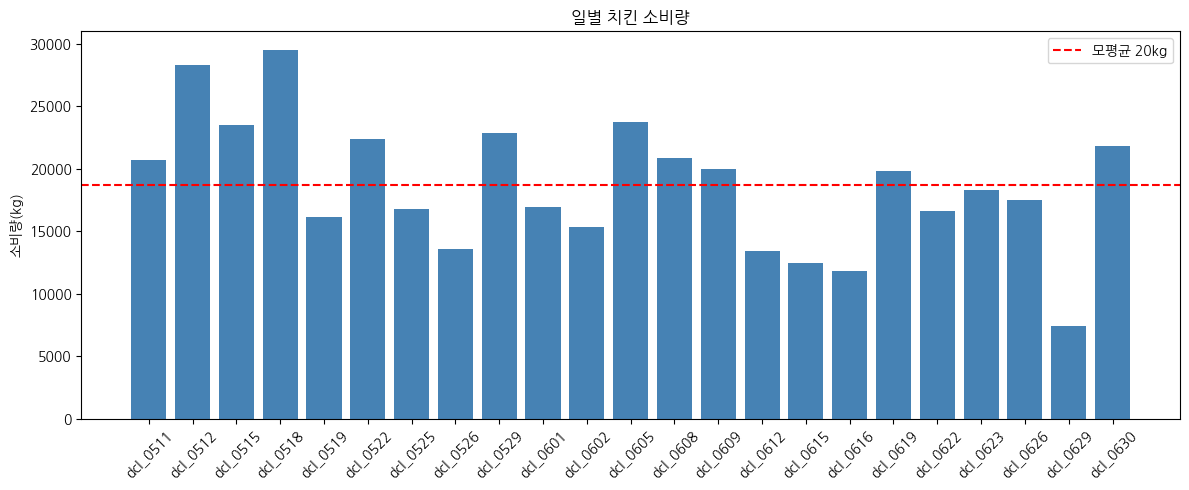

In [ ]:
from numpy import mean
plt.figure (figsize=(12,5))


plt.bar(df['dcl_id'],df['sum_g'], color='steelblue')
plt.axhline(y=df['sum_g'].mean(), color='red', linestyle='--', label='모평균 20kg')
plt.xticks(rotation=45)
plt.ylabel('소비량(kg)')
plt.title('일별 치킨 소비량')
plt.legend()
plt.tight_layout()
plt.show()

---
## EDA — 분포 및 이상치 확인

> 원래 분석 계획(1. EDA → 2. 가설 검증)상 이 단계가 있어야 했으나, 실제로는 막대그래프 하나만 그리고 바로 정규성 검정(가설 검증의 사전 절차)으로 넘어갔었다. Shapiro-Wilk·Levene 검정은 '가설검정의 전제조건 확인'이지 '데이터가 대체로 어떻게 생겼는지 파악하는' EDA와는 목적이 다르므로, 아래에 누락됐던 EDA를 보완한다.


### 요일별 요약 통계


In [ ]:
summary = df.groupby('day_of_week')['sum_g'].describe()
print(summary)


             count          mean          std      min      25%      50%  \
day_of_week                                                                
금              7.0  20457.142857  3820.496103  13450.0  18650.0  22400.0   
월              8.0  17643.750000  6482.583122   7400.0  15562.5  16850.0   
화              8.0  18162.500000  5243.754789  11850.0  14900.0  17225.0   

                 75%      max  
day_of_week                    
금            23150.0  23750.0  
월            20700.0  29500.0  
화            20450.0  28300.0  


### 요일별 분포 — Boxplot


<Figure size 800x500 with 0 Axes>

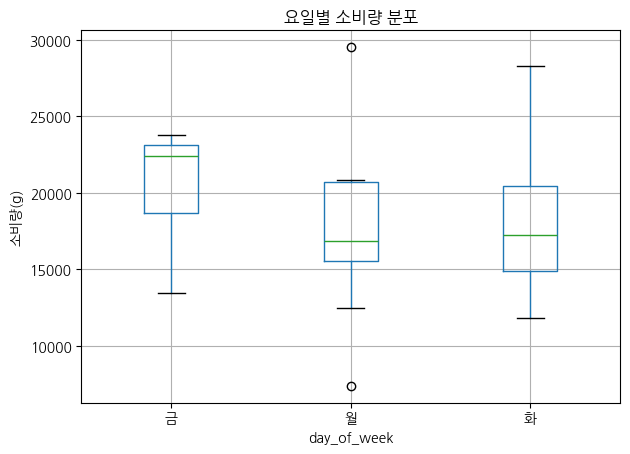

In [ ]:
plt.figure(figsize=(8, 5))
df.boxplot(column='sum_g', by='day_of_week')
plt.title('요일별 소비량 분포')
plt.suptitle('')
plt.ylabel('소비량(g)')
plt.tight_layout()
plt.show()


### 이상치 스캔 (IQR 기준)


In [ ]:
q1 = df['sum_g'].quantile(0.25)
q3 = df['sum_g'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = df[(df['sum_g'] < lower) | (df['sum_g'] > upper)]
print(f"IQR 범위: [{lower:.0f}, {upper:.0f}]")
print(f"이상치 개수: {len(outliers)}")
print(outliers)


IQR 범위: [6225, 31625]
이상치 개수: 0
Empty DataFrame
Columns: [dcl_id, day_of_week, sum_g]
Index: []


---
## 모평균 20kg과 일표본 T검정 (H1 사전 확인)


### 표본 정규성 검증


In [ ]:
check_normality(df['sum_g'], '전체 표본')


[전체 표본] 샤피로 윌크: 통계량=0.9860, p-value=0.9796
  → 정규성 만족


(np.float64(0.9860215464006842), np.float64(0.9796192024032054))

In [ ]:
stat, p = stats.ttest_1samp(df['sum_g'], popmean=20000)
print(f't검정: 통계량={stat:.4f}, p-value={p:.4f}')

if p < 0.05:
    print('귀무가설 기각 → 일평균 소비량은 20kg이 아니다')
else:
    print('귀무가설 채택 → 일평균 소비량은 20kg과 유의미한 차이 없다')

t검정: 통계량=-1.2047, p-value=0.2411
귀무가설 채택 → 일평균 소비량은 20kg과 유의미한 차이 없다


---
### 요일별 주문 소비량 차이 가설 (H1, ANOVA)
## 범주별 데이터 10개 미만으로 샤피로 정규성 검정


In [ ]:
mon_data=df[df['day_of_week']=='월']
tue_data=df[df['day_of_week']=='화']
fri_data=df[df['day_of_week']=='금']

In [ ]:
for label, group in [('월', mon_data), ('화', tue_data), ('금', fri_data)]:
    check_normality(group['sum_g'], label)


[월] 샤피로 윌크: 통계량=0.9537, p-value=0.7481
  → 정규성 만족
[화] 샤피로 윌크: 통계량=0.9466, p-value=0.6773
  → 정규성 만족
[금] 샤피로 윌크: 통계량=0.8546, p-value=0.1355
  → 정규성 만족


## 등분산성 확인


In [ ]:
check_variance_homogeneity(mon_data['sum_g'], tue_data['sum_g'], fri_data['sum_g'],
                            labels=['월', '화', '금'])


Levene 검정 (월, 화, 금): 통계량=0.3508, p-value=0.7084
  → 등분산 동일


(np.float64(0.35077786637098424), np.float64(0.7083862376430077))

## 등분산 및 정규성 입증 후 ANOVA 분산 분석 시행


In [ ]:
anova=stats.f_oneway(mon_data['sum_g'],tue_data['sum_g'],fri_data['sum_g'])
print(f'F-statistic: {anova.statistic:.4f}, p-value: {anova.pvalue:.4f}')

F-statistic: 0.5719, p-value: 0.5734


### 귀무가설 기각 X
### 요일별 평균 차이는 유의하지 아니함


---
# H2. 평일 주중과 연휴 및 연휴전날 평균 소비량 차이
### 고정 요일이 월,화,금 임으로 평일 과 주말 연휴 전날의 평균 소비량 차이 확인
### 데이터 갯수는 월화 (평일) 금(연휴전일) 로 불균형 존재


In [ ]:
H2_data=pd.read_csv('/content/H2.csv')
H2_data.head()

,dcl_id,day_status,sum_g
0,dcl_0511,0,20650
1,dcl_0512,0,28300
2,dcl_0515,1,23450
3,dcl_0518,0,29500
4,dcl_0519,0,16150


In [ ]:
group_mean = H2_data.groupby('day_status')['sum_g'].mean()
group_mean

,sum_g
day_status,
0,18073.333333
1,19818.750000


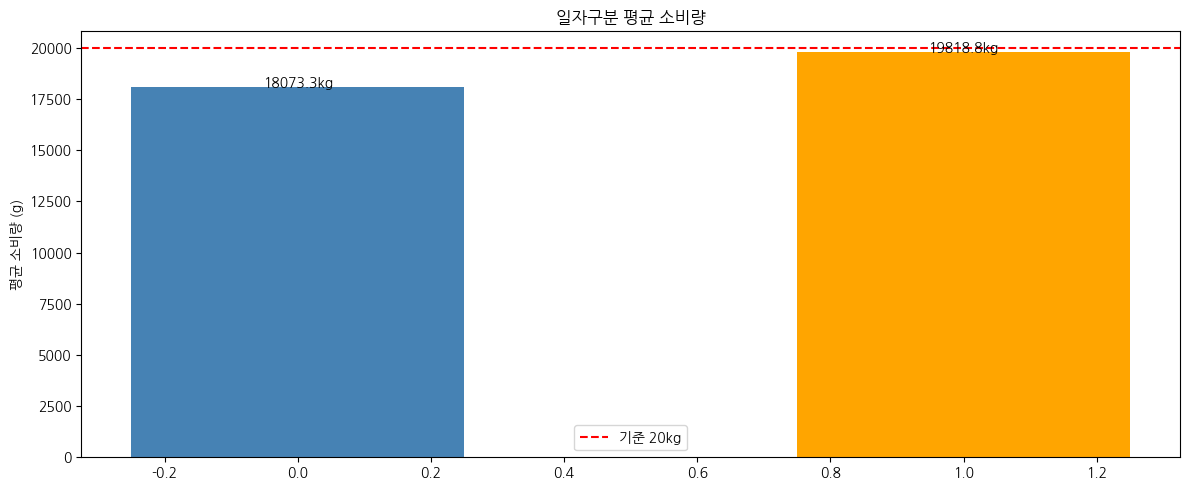

In [ ]:
plt.figure(figsize=(12,5))


bars = plt.bar(group_mean.index, group_mean.values,
               color=['steelblue', 'orange'], width=0.5)

# 막대 위에 값 표시
for bar, val in zip(bars, group_mean.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}kg', ha='center')

plt.axhline(y=20000, color='red', linestyle='--', label='기준 20kg')
plt.ylabel('평균 소비량 (g)')
plt.title('일자구분 평균 소비량')
plt.legend()
plt.tight_layout()
plt.show()

## 정규성 검증


In [ ]:
for x in H2_data['day_status'].unique():
    label = '평일' if x == 0 else '휴일전일'
    check_normality(H2_data[H2_data['day_status'] == x]['sum_g'], label)


[평일] 샤피로 윌크: 통계량=0.9615, p-value=0.7189
  → 정규성 만족
[휴일전일] 샤피로 윌크: 통계량=0.8838, p-value=0.2047
  → 정규성 만족


In [ ]:
group_0=H2_data[H2_data['day_status']==0]
group_1= H2_data[H2_data['day_status'] == 1]

## 등분산 검정


In [ ]:
check_variance_homogeneity(group_0['sum_g'], group_1['sum_g'], labels=['평일', '휴일전일'])


Levene 검정 (평일, 휴일전일): 통계량=0.4389, p-value=0.5148
  → 등분산 동일


(np.float64(0.43892868339789676), np.float64(0.5148460940764392))

## 독립표본 검정


In [ ]:
t,p = stats.ttest_ind(group_0['sum_g'],group_1['sum_g'],equal_var=True)
print(f't검정: 통계량={t:.4f}, p-value={p:.4f}')
if p > 0.05:
  print("귀무가설 채택")
else :
  print("귀무가설 기각")


t검정: 통계량=-0.7514, p-value=0.4607
귀무가설 채택


In [ ]:
summary_df = pd.DataFrame({
    'GROUP':['group_0','group_1'],
    'N': [len(group_0),len(group_1)],
    '평균 소비량': [group_0['sum_g'].mean(), group_1['sum_g'].mean()],
    '표준편차': [group_0['sum_g'].std(), group_1['sum_g'].std()],
    '표준오차': [group_0['sum_g'].sem(), group_1['sum_g'].sem()]
})


In [ ]:
print(summary_df)

     GROUP   N        평균 소비량         표준편차         표준오차
0  group_0  15  18073.333333  5860.091012  1513.068993
1  group_1   8  19818.750000  3971.320175  1404.073713


---
## H3. 오후 주문 소비와 저녁 주문 소비의 차이가 발생한가
### 날짜 변화 통제를 위해 대응표본 t검정 시행


In [ ]:
H3_DATA=pd.read_csv('/content/H3.csv')
H3_DATA.head()

,dcl_id,date,day_of_week,end_g,16:00,16:30,17:00,17:30,18:00,18:30,...,roll_prev_3days_mean_t2,roll_same_3days_mean_t2,roll_prev_5days_mean_t1,roll_prev_5days_mean_t2,lag_prev_t1_ratio,lag_same_t1_ratio,lag_prev_t2_ratio,lag_same_t2_ratio,prev_sum_g,same_prev_sum_g
0,dcl_0515,2026-05-15,금,8100,2100,1550,0,1000,0,1800,...,NaN,NaN,NaN,NaN,0.59,NaN,0.41,NaN,28300.0,NaN
1,dcl_0522,2026-05-22,금,1245,500,500,0,1650,2850,0,...,11666.67,NaN,12450.0,11160.0,0.57,0.52,0.43,0.48,16150.0,23450.0
2,dcl_0529,2026-05-29,금,6158,750,750,0,2000,2300,0,...,6700.00,NaN,10880.0,8790.0,0.66,0.46,0.34,0.54,13550.0,22400.0
3,dcl_0605,2026-06-05,금,538,0,0,750,0,900,4400,...,7200.00,11350.0,11170.0,5920.0,0.72,0.53,0.28,0.47,15350.0,22850.0
4,dcl_0612,2026-06-12,금,2230,750,0,500,1550,2200,0,...,8950.00,12300.0,11850.0,7530.0,0.73,0.41,0.27,0.59,20000.0,23750.0


In [ ]:
h3_data=H3_DATA[['dcl_id','day_of_week','cumul_16_19','cumul_20_22']]
h3_data.head()

,dcl_id,day_of_week,cumul_16_19,cumul_20_22
0,dcl_0515,금,12300,11150
1,dcl_0522,금,10300,12100
2,dcl_0529,금,12050,10800
3,dcl_0605,금,9750,14000
4,dcl_0612,금,6650,6800


In [ ]:

diff = h3_data['cumul_16_19'] - h3_data['cumul_20_22']

# 1. 정규성 검정 (차이값 기준)
shapiro_stat, shapiro_p = stats.shapiro(diff)
print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

# 2. 이상치 확인
print(diff.describe())

# 3. 정규성 만족 시 -> paired t-test
t_stat, t_p = stats.ttest_rel(h3_data['cumul_16_19'], h3_data['cumul_20_22'])
print(f"Paired t-test: t={t_stat:.4f}, p={t_p:.4f}")

# 4. 정규성 위반 시 -> Wilcoxon signed-rank test (비모수 대안)
w_stat, w_p = stats.wilcoxon(h3_data['cumul_16_19'], h3_data['cumul_20_22'])
print(f"Wilcoxon: stat={w_stat:.4f}, p={w_p:.4f}")

Shapiro-Wilk: stat=0.9661, p=0.5955
count      23.000000
mean     2219.565217
std      3965.439880
min     -4300.000000
25%     -1150.000000
50%      2250.000000
75%      4650.000000
max      9950.000000
dtype: float64
Paired t-test: t=2.6844, p=0.0135
Wilcoxon: stat=56.0000, p=0.0126


### 두 시간대 주문 소비 차이 는 대략 2.2kg으로 유의미한 차이로 보여짐
### diff=(오후)-(저녁)임으로 t값의 양수부호로 오후 판매량 > 저녁 판매량을 의미


In [ ]:
cohens_d = diff.mean() / diff.std()
print(f"Cohen's d: {cohens_d:.4f}")

Cohen's d: 0.5597


### 실제 효과 크기 차이도 0.56으로 중간 정도의 차이를 보임
